In [4]:
#  create masked dataset from images in a folder
import numpy as np
from pathlib import Path
from PIL import Image

def create_masked_image(image_array, patch_size=8, mask_ratio=0.5, seed=121225):
    if image_array.shape[0] % patch_size != 0 or image_array.shape[1] % patch_size != 0:
        raise ValueError(f"Image dimensions {image_array.shape} must be divisible by patch size {patch_size}.")

    h, w = image_array.shape
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size

    patches = image_array.reshape(num_patches_h, patch_size, num_patches_w, patch_size)
    patches = patches.transpose(0, 2, 1, 3)
    flat_patches = patches.reshape(num_patches_h * num_patches_w, patch_size, patch_size)

    np.random.seed(seed)
    num_total_patches = flat_patches.shape[0]
    num_patches_to_mask = min(num_total_patches, int(round(num_total_patches * mask_ratio)))

    masked_patch_indices = np.random.choice(num_total_patches, size=num_patches_to_mask, replace=False)
    masked_patches_array = flat_patches.copy()
    masked_patches_array[masked_patch_indices] = 0

    reconstructed_image = masked_patches_array.reshape(num_patches_h, num_patches_w, patch_size, patch_size)
    reconstructed_image = reconstructed_image.transpose(0, 2, 1, 3).reshape(h, w)

    return reconstructed_image

def create_masked_dataset(input_dir,
                          output_dir,
                          patch_size=16,
                          mask_ratio=0.5,
                          seed=121525,
                          extensions=(".tif",),
                          recursive=False,
                          resize=None):
    """Create masked copies of every image in a folder using create_masked_image."""
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    extensions = tuple(e if e.startswith('.') else f'.{e}' for e in extensions)
    files = sorted(
        p for p in (input_dir.rglob('*') if recursive else input_dir.glob('*'))
        if p.suffix.lower() in extensions and p.is_file()
    )

    if not files:
        raise ValueError(f"No files with extensions {extensions} found in {input_dir}.")

    for idx, path in enumerate(files):
        rng_seed = None if seed is None else seed + idx
        img = Image.open(path).convert('L')
        if resize:
            img = img.resize((resize, resize))
        arr = np.array(img, dtype=np.uint8)
        masked = create_masked_image(
            arr,
            patch_size=patch_size,
            mask_ratio=mask_ratio,
            seed=rng_seed,
        )
        out_path = output_dir / path.name
        Image.fromarray(masked.astype(np.uint8)).save(out_path)
        print(f"Saved masked image: {out_path}")

    print(f"Created {len(files)} masked image(s) inside {output_dir}.")


create_masked_dataset(
    input_dir='/home/tali1/rat_brain_seg/data/dataset_split_70_10_20/train/images',
    output_dir='/home/tali1/rat_brain_seg/data/masked_training_images',
    patch_size=16,
    mask_ratio=0.5,
    seed=121525,
    resize=256,
)


Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_0.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_1.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_10.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_2.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_3.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_4.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_5.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_6.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_7.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_8.tif
Saved masked image: /home/tali1/rat_brain_seg/data/masked_training_images/10c_slice_9.tif
Saved mas

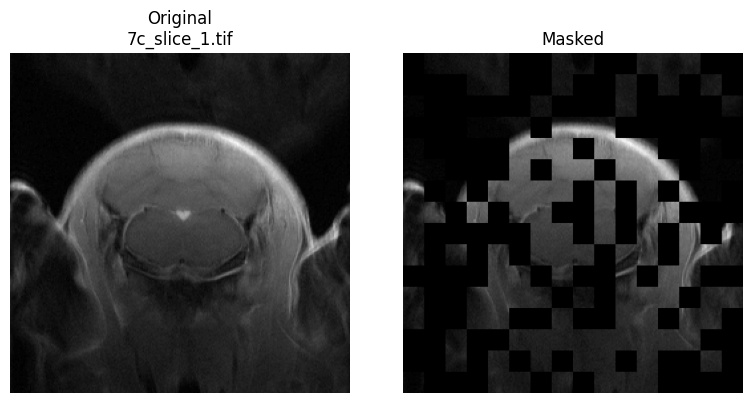

In [8]:
# visualize some results
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

original_dir = Path('/home/tali1/rat_brain_seg/data/dataset_split_70_10_20/train/images')
masked_dir = Path('/home/tali1/rat_brain_seg/data/masked_training_images')

all_images = sorted([p for p in original_dir.glob('*.tif')])
if not all_images:
    raise ValueError(f'No source images found in {original_dir}')


def visualize_pair(index=None):
    """Plot the original image and its masked counterpart."""
    if index is None:
        index = random.randrange(len(all_images))
    orig_path = all_images[index]
    masked_path = masked_dir / orig_path.name
    if not masked_path.exists():
        raise FileNotFoundError(f"Masked file missing: {masked_path}")

    orig = Image.open(orig_path).convert('L')
    masked = Image.open(masked_path).convert('L')

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(orig, cmap='gray')
    axes[0].set_title(f'Original\n{orig_path.name}')
    axes[0].axis('off')

    axes[1].imshow(masked, cmap='gray')
    axes[1].set_title('Masked')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


visualize_pair()
